In [1]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader , TensorDataset
from torchvision.utils import save_image, make_grid
from torch.optim import Adam
import torch.nn.init as init

import numpy as np
import math

import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import MultipleLocator
import matplotlib.cm as cm
from matplotlib.cm import get_cmap

import copy
import seaborn as sns

from scipy.stats import norm
from sklearn.neighbors import KernelDensity, LocalOutlierFactor
from sklearn.decomposition import PCA

import tqdm
import pickle

# MI estimators
# from utils.estimators import *

In [2]:
NUM_POLICY = 5

# Load flat/rough/cut weight dataset
# terrain = {"flat" :[], "rough":[] , "weight":[]}
# for i in terrain.keys(): # each run have 3 policies
#     for policy in range(NUM_POLICY):
#         terrain[i].append(np.load(f"../data/eval/new_pol2/{i}-policy_{policy}.npy" , allow_pickle=True).item())
# for key, value in terrain.items():
#     terrain[key] = np.array(value)

# # Load sensory albation dataset
# sensor_loss = {"full":[] , "no_pos":[] , "no_vel":[], "no_action":[], "no_IMU":[] , "no_fc":[]}
# for i,keys in enumerate(sensor_loss.keys()):
#     for policy in range(NUM_POLICY):    
#         sensor_loss[keys].append(np.load(f"../data/eval/new_pol2/case_{i}-policy_{policy}.npy" , allow_pickle=True).item())
# for key, value in sensor_loss.items():
#     sensor_loss[key] = np.array(value)

# motor_dataset = {f"motor{i}" :[] for i in range(5)}
# for i in motor_dataset.keys(): # each run have 3 policies
#     for policy in range(NUM_POLICY):
#         motor_dataset[i].append(np.load(f"../data/important/new_pol2/{i}-policy_{policy}.npy" , allow_pickle=True).item())
# for key, value in motor_dataset.items():
#     motor_dataset[key] = np.array(value)

mode=["full","vel_act", "pos_act", "pos_vel_act", "act_FC", "act_IMU_FC", "pos_act_IMU", "pos_act_FC", "vel_act_IMU", "vel_act_FC"]
important_dataset = {key : [] for key in mode}
for i in important_dataset.keys(): # each run have 3 policies
    for policy in range(NUM_POLICY):
        important_dataset[i].append(np.load(f"../data/flat/flat-{i}-policy_{policy}.npy" , allow_pickle=True).item())
for key, value in important_dataset.items():
    important_dataset[key] = np.array(value)


# [case:str][number_file:int][data/brain:str]

In [3]:
selected_dataset = important_dataset

In [13]:
def preprocess(selected_dataset , num_pol):
    performance = {f"policy{n_policy}": {case: [] for case in selected_dataset.keys()} for n_policy in range(num_pol)}
    max_distance = {f"policy{n_policy}": {case: [] for case in selected_dataset.keys()} for n_policy in range(num_pol)}
    avg_vel = {f"policy{n_policy}": {case: [] for case in selected_dataset.keys()} for n_policy in range(num_pol)}

    for policy in range(num_pol):
        for case in selected_dataset.keys():
            reward = np.sum(selected_dataset[case][policy]["data"]['reward'], axis=0)
            performance[f"policy{policy}"][case] = reward

            max_pos_x = np.max(selected_dataset[case][policy]["data"]['pos_x'], axis=0)
            max_distance[f"policy{policy}"][case] = max_pos_x

            vel_x = selected_dataset[case][policy]["data"]['vel_b'][:,:,0]
            avg_vel[f"policy{policy}"][case] = np.mean(vel_x ,axis=0)
    return performance , max_distance , avg_vel

def preprocess_combined(selected_dataset, num_pol):
    """
    Combine values from ALL policies into one 'policy_all' per case.

    Returns:
        performance_all, max_distance_all, avg_vel_all
        # Each is a dict like:
        # {
        #   'policy_all': {
        #       <case_a>: np.ndarray(... concatenated from all policies ...),
        #       <case_b>: np.ndarray(...),
        #       ...
        #   }
        # }
    """
    cases = list(selected_dataset.keys())

    # Buckets (lists) to collect per-policy arrays before concatenating
    perf_bucket = {case: [] for case in cases}
    dist_bucket = {case: [] for case in cases}
    vel_bucket  = {case: [] for case in cases}

    for policy in range(num_pol):
        for case in cases:
            data = selected_dataset[case][policy]["data"]

            # 1) reward sum over time -> shape (..., ?) then flatten along new axis 0
            reward = np.sum(data["reward"], axis=0)
            perf_bucket[case].append(np.ravel(reward))

            # 2) max pos_x over time
            max_pos_x = np.max(data["pos_x"], axis=0)
            dist_bucket[case].append(np.ravel(max_pos_x))

            # 3) avg vel_x over time (take x component from vel_b[..., 0])
            vel_x = data["vel_b"][:, :, 0]
            avg_vel_x = np.mean(vel_x, axis=0)
            vel_bucket[case].append(np.ravel(avg_vel_x))

    # Concatenate across all policies so each case has one long vector
    performance_all = {"policy_all": {case: np.concatenate(perf_bucket[case], axis=0) if len(perf_bucket[case]) else np.array([]) for case in cases}}
    max_distance_all = {"policy_all": {case: np.concatenate(dist_bucket[case], axis=0) if len(dist_bucket[case]) else np.array([]) for case in cases}}
    avg_vel_all = {"policy_all": {case: np.concatenate(vel_bucket[case], axis=0) if len(vel_bucket[case]) else np.array([]) for case in cases}}

    return performance_all, max_distance_all, avg_vel_all

In [12]:
num_pol = 5
performance , max_distance , avg_vel= preprocess(selected_dataset=selected_dataset , num_pol=num_pol)

print(performance.keys())  # Prints the policy keys
print(performance["policy0"].keys())  # Prints the case keys under "policy0"
print(max_distance.keys())  # Prints the policy keys
print(max_distance["policy0"].keys())  # Prints the case keys under "policy0"
# [num_policy][data group][data inside]


dict_keys(['policy0', 'policy1', 'policy2', 'policy3', 'policy4'])
dict_keys(['full', 'vel_act', 'pos_act', 'pos_vel_act', 'act_FC', 'act_IMU_FC', 'pos_act_IMU', 'pos_act_FC', 'vel_act_IMU', 'vel_act_FC'])
dict_keys(['policy0', 'policy1', 'policy2', 'policy3', 'policy4'])
dict_keys(['full', 'vel_act', 'pos_act', 'pos_vel_act', 'act_FC', 'act_IMU_FC', 'pos_act_IMU', 'pos_act_FC', 'vel_act_IMU', 'vel_act_FC'])


In [5]:
def plot_performance(performance , title:str="Performance",ylim=350):
    num_col = len(performance.keys())  # Number of policies (columns)

    # --- CHANGED: dynamic subplot grid (max 2 columns; 1x1 if only one) ---
    ncols = 1 if num_col == 1 else min(2, num_col)
    nrows = 1 if num_col == 1 else math.ceil(num_col / 2)
    fig, axes = plt.subplots(nrows, ncols, figsize=(12, 6*nrows))
    # Flatten axes to 1D list for easy indexing
    if isinstance(axes, np.ndarray):
        axes = axes.flatten()
    else:
        axes = [axes]
    # ---------------------------------------------------------------------

    num_group = len(performance['policy0'].keys())  # Number of cases (groups)
    pastel_colors = sns.color_palette("pastel", n_colors=num_group)
    case_colors = {case: pastel_colors[i] for i, case in enumerate(list(performance['policy0'].keys()))}
    # Compute global max across all policies and cases
    global_max = max(
        [val for policy in performance.values() for case_vals in policy.values() for val in case_vals]
    )
    for i, policy in enumerate(performance.keys()):
        ax = axes[i]  # Get the axis for this policy subplot
        box = ax.boxplot(
            [performance[policy][case] for case in performance[policy].keys()],  # List of data for each case
            vert=True, patch_artist=True, zorder=1  # fill with color  # Set the tick labels to be the case names
        )
        ax.set_xticklabels(list(performance[policy].keys()), fontsize=8 ,rotation=45) 
        for j, patch in enumerate(box['boxes']):
            case = list(performance[policy].keys())[j]  # Get the case corresponding to the current box
            patch.set_facecolor(case_colors[case])  # Set the color for the box based on the case
        ax.set_ylim(0, ylim)  # Add a little padding
        # ax.set_ylim(0, global_max)  # Add a little padding

        for j, case in enumerate(performance[policy].keys()):
            x_vals = [j + 1 + np.random.normal(0, 0.1) for _ in performance[policy][case]]  # Jitter with normal noise
            ax.scatter(x_vals, performance[policy][case], alpha=0.8, s=5, label=case, zorder=2)
        ax.set_title(f"{title} for {policy}")

    # Hide any unused axes (when grid > number of policies)
    for k in range(len(performance.keys()), len(axes)):
        axes[k].set_visible(False)

    plt.tight_layout()
    plt.show()

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict

def _flatten_values(perf):
    """Return a flat list of all numeric values in the nested dict."""
    vals = []
    for pol in perf.values():
        for case_vals in pol.values():
            vals.extend(list(case_vals))
    return np.asarray(vals, dtype=float)

def _compute_norms(performance, normalize):
    """Return normalization denominators matching the normalize mode."""
    if normalize == 'global':
        denom = np.nanmax(_flatten_values(performance))
        return {'_global': denom if denom != 0 else 1.0}
    elif normalize == 'per_policy':
        d = {}
        for p, pol in performance.items():
            vmax = np.nanmax([np.nanmax(v) if len(v) else 0 for v in pol.values()])
            d[p] = vmax if vmax != 0 else 1.0
        return d
    elif normalize == 'per_case':
        # Same denominator for the same case across policies
        d = defaultdict(float)
        all_cases = set()
        for pol in performance.values():
            all_cases.update(pol.keys())
        for c in all_cases:
            vmax = np.nanmax([np.nanmax(performance[p].get(c, [])) 
                              if len(performance[p].get(c, [])) else 0
                              for p in performance.keys()])
            d[c] = vmax if vmax != 0 else 1.0
        return d
    else:
        raise ValueError("normalize must be one of: 'global', 'per_policy', 'per_case'")

def _to_percentages(performance, normalize='global'):
    """Convert raw performance values to percentages according to normalization."""
    norms = _compute_norms(performance, normalize)
    pct = {}
    for p, pol in performance.items():
        pct[p] = {}
        for c, arr in pol.items():
            arr = np.asarray(arr, dtype=float)
            if normalize == 'global':
                denom = norms['_global']
            elif normalize == 'per_policy':
                denom = norms[p]
            elif normalize == 'per_case':
                denom = norms[c]
            pct[p][c] = (arr / denom * 100.0) if denom != 0 else np.zeros_like(arr)
    return pct

def _summary_stats(values, whisker_mode='minmax'):
    """
    Return dict with stats required to draw 'boxplot-like' boundaries.
    whisker_mode: 'minmax' or 'p5p95'
    """
    v = np.asarray(values, dtype=float)
    v = v[~np.isnan(v)]
    if v.size == 0:
        return {'mean': 0, 'median': 0, 'q1': 0, 'q3': 0, 'wlo': 0, 'whi': 0}
    q1, median, q3 = np.percentile(v, [25, 50, 75])
    mean = float(np.mean(v))
    if whisker_mode == 'p5p95':
        wlo, whi = np.percentile(v, [5, 95])
    else:
        wlo, whi = float(np.min(v)), float(np.max(v))
    return {'mean': mean, 'median': median, 'q1': q1, 'q3': q3, 'wlo': wlo, 'whi': whi}

def plot_performance_pct_bar(
    performance,
    title="Performance (%)",
    normalize='global',      # 'global' | 'per_policy' | 'per_case'
    aggregate='median',      # 'median' | 'mean'
    whisker_mode='minmax',   # 'minmax' | 'p5p95'
    iqr_box_alpha=0.35,
    bar_alpha=0.85,
    figsize=(14, 4),
    ylim=(0, 110)
):
    """
    Render a single ROW of subplots (one per policy) with bars per case.
    Each bar height = aggregate of percent values; boxplot-like boundaries overlaid.
    """
    # Convert to percents
    pct = _to_percentages(performance, normalize=normalize)

    policies = list(pct.keys())
    cases = list(next(iter(pct.values())).keys())  # assume same keys per policy
    num_policies = len(policies)
    num_cases = len(cases)

    # Consistent colors by case
    palette = sns.color_palette("pastel", n_colors=num_cases)
    case_color = {c: palette[i] for i, c in enumerate(cases)}

    fig, axes = plt.subplots(1, num_policies, figsize=figsize, sharey=True)
    if num_policies == 1:
        axes = [axes]

    for i, p in enumerate(policies):
        ax = axes[i]

        # x positions for bars
        x = np.arange(num_cases)
        width = 0.8

        # Compute stats per case
        stats = {}
        heights = []
        for c in cases:
            s = _summary_stats(pct[p][c], whisker_mode=whisker_mode)
            stats[c] = s
            if aggregate == 'mean':
                heights.append(s['mean'])
            else:
                heights.append(s['median'])
        heights = np.array(heights)

        # Bars for aggregate
        bars = ax.bar(x, heights, width=width, alpha=bar_alpha,
                      color=[case_color[c] for c in cases], edgecolor='black', linewidth=0.8)

        # Draw IQR boxes and whiskers on top of each bar
        for xi, c in zip(x, cases):
            s = stats[c]
            # IQR rectangle (Q1 to Q3)
            iqr_height = s['q3'] - s['q1']
            ax.add_patch(plt.Rectangle(
                (xi - width/4, s['q1']),
                width/2,
                iqr_height,
                fill=True,
                alpha=iqr_box_alpha,
                edgecolor='black',
                linewidth=0.8
            ))
            # Whiskers (vertical lines)
            ax.plot([xi, xi], [s['wlo'], s['q1']], lw=1.2, color='black')
            ax.plot([xi, xi], [s['q3'], s['whi']], lw=1.2, color='black')
            # Whisker caps
            cap = width/4
            ax.plot([xi - cap, xi + cap], [s['wlo'], s['wlo']], lw=1.2, color='black')
            ax.plot([xi - cap, xi + cap], [s['whi'], s['whi']], lw=1.2, color='black')
            # Median marker
            ax.plot([xi - cap, xi + cap], [s['median'], s['median']], lw=1.6, color='black')

        ax.set_title(f"{title} – {p}")
        ax.set_xticks(x)
        ax.set_xticklabels(cases, rotation=45, fontsize=9)
        ax.set_ylim(*ylim)
        ax.set_ylabel("%" if i == 0 else "")
        ax.grid(axis='y', linestyle='--', alpha=0.25)

    # Legend for cases (colors of bars)
    handles = [plt.Line2D([0],[0], marker='s', color='w', markerfacecolor=case_color[c],
                          markeredgecolor='black', label=c) for c in cases]
    fig.legend(handles=handles, loc='upper center', ncol=min(6, num_cases), frameon=False)

    fig.tight_layout(rect=[0, 0, 1, 0.92])
    plt.show()


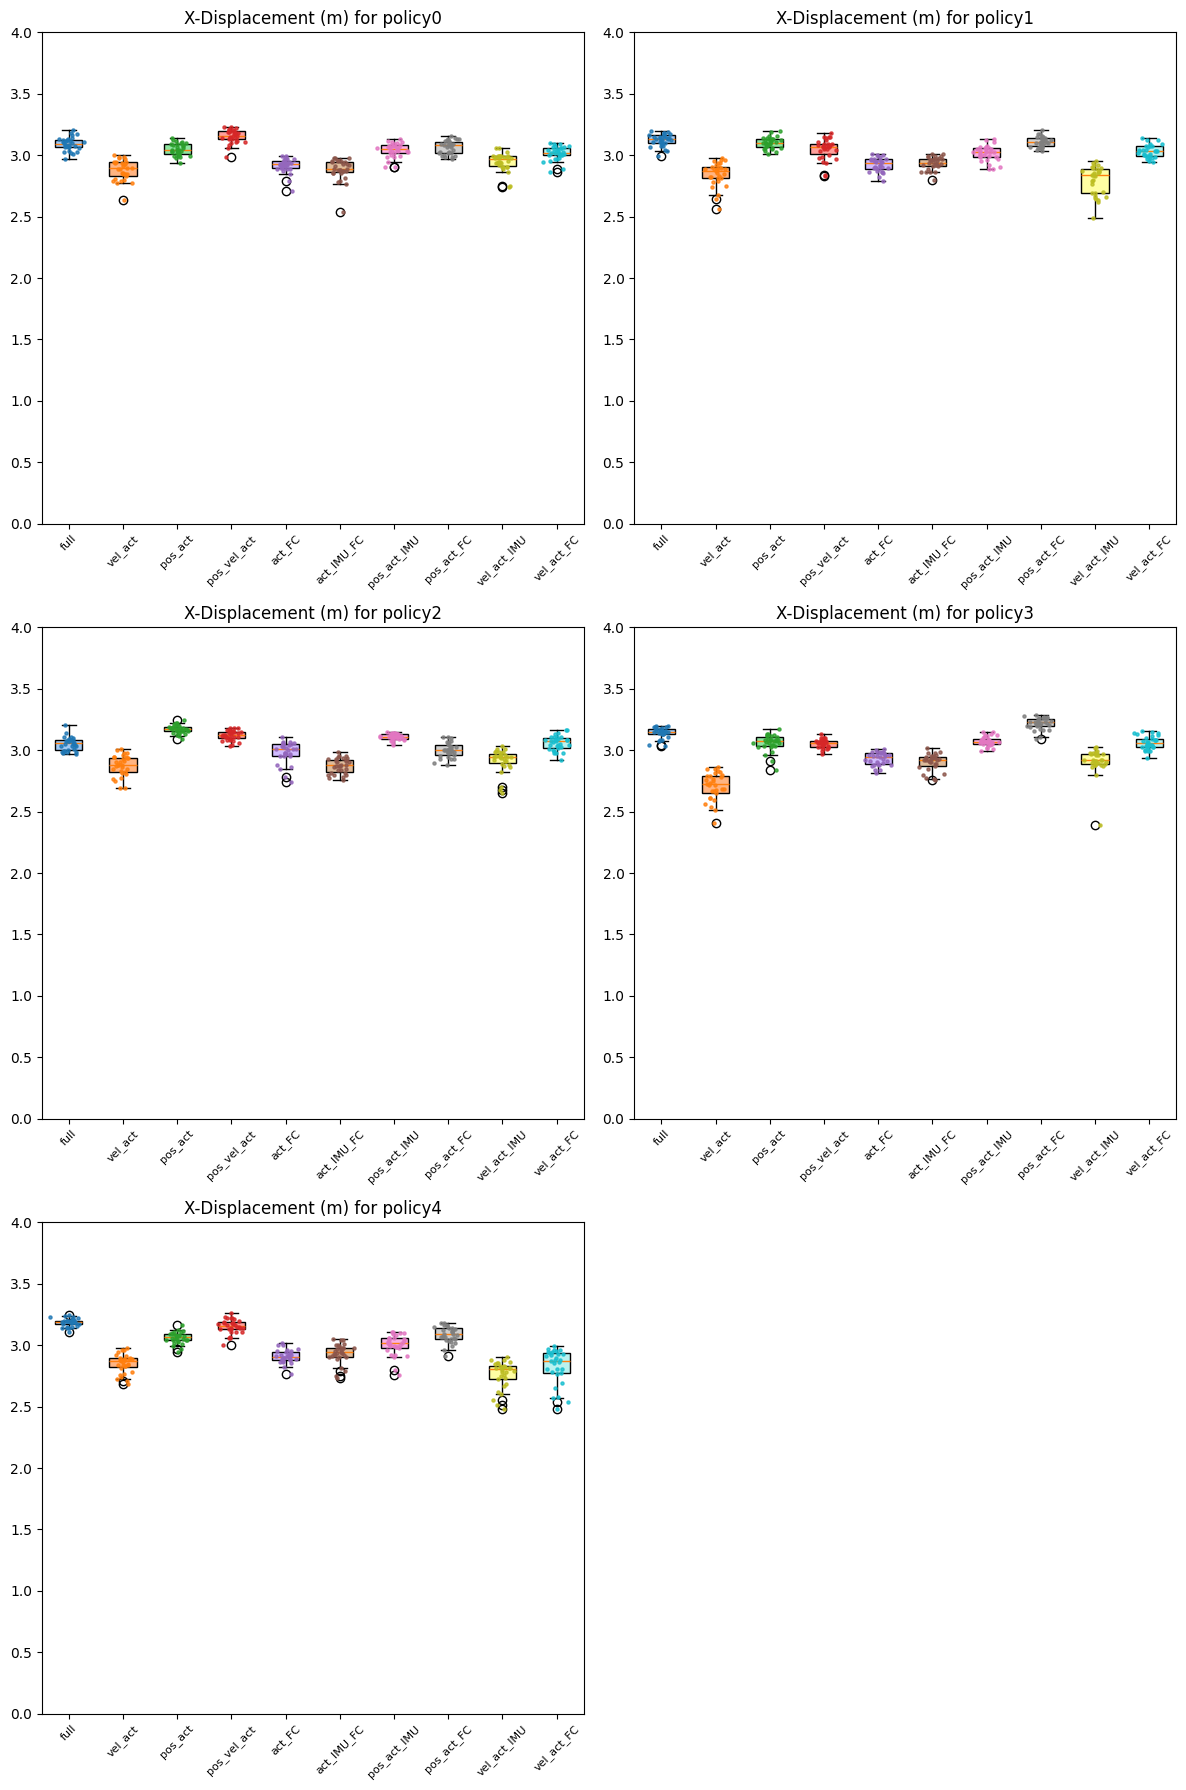

In [7]:
# plot_performance(performance, title="reward" ,ylim=350)
# plot_performance_pct_bar(performance, normalize='per_policy')
plot_performance(max_distance, title="X-Displacement (m)",ylim=4)

In [8]:
def plot_performance_all_in_one(performance: dict, title: str = "Performance (All Policies)" , ylim=350):
    policies = list(performance.keys())
    if not policies:
        raise ValueError("performance must contain at least one policy")

    # Stable case order
    first_cases = list(performance[policies[0]].keys())
    all_cases = set(first_cases)
    for p in policies[1:]:
        all_cases |= set(performance[p].keys())
    case_order = first_cases + [c for c in all_cases if c not in first_cases]

    num_cases = len(case_order)
    num_policies = len(policies)

    pastel_colors = sns.color_palette("pastel", n_colors=num_cases)
    case_colors = {case: pastel_colors[i] for i, case in enumerate(case_order)}

    fig, ax = plt.subplots(1, 1, figsize=(12, 6))

    group_width = 0.8
    box_width = group_width / max(2, num_policies)
    offsets = np.linspace(-group_width/2 + box_width/2, group_width/2 - box_width/2, num_policies)

    for i, policy in enumerate(policies):
        # Ensure each is a list/array (empty allowed)
        data = [np.asarray(performance[policy].get(case, [])) for case in case_order]
        positions = [j + offsets[i] for j in range(1, num_cases + 1)]

        box = ax.boxplot(
            data,
            positions=positions,
            widths=box_width * 0.9,
            vert=True,
            patch_artist=True,
            zorder=1
        )

        # Color by case
        for j, patch in enumerate(box['boxes']):
            patch.set_facecolor(case_colors[case_order[j]])

        # Scatter with safe empties
        for j, vals in enumerate(data):
            if vals.size == 0:
                continue
            x_center = positions[j]
            x_vals = x_center + np.random.normal(0, box_width * 0.12, size=vals.size)
            ax.scatter(x_vals, vals, alpha=0.8, s=5, zorder=2)

    ax.set_xticks(range(1, num_cases + 1))
    ax.set_xticklabels(case_order, fontsize=8, rotation=45)
    ax.set_ylim(0, ylim)
    ax.set_title(title)

    handles = [plt.Line2D([0],[0], marker='s', linestyle='',
                          markerfacecolor=case_colors[c], markeredgecolor='k', markersize=8, label=c)
               for c in case_order]
    ax.legend(handles=handles, title="Case", loc='lower right', fontsize=8)

    plt.tight_layout()
    plt.show()

    # --- Return averages (NumPy-safe empties) ---
    policy_case_mean = {}
    for p in policies:
        case_means = {}
        for c in case_order:
            vals = np.asarray(performance[p].get(c, []))
            case_means[c] = float(np.mean(vals)) if vals.size > 0 else float('nan')
        policy_case_mean[p] = case_means

    overall_case_mean = {}
    for c in case_order:
        all_vals = []
        for p in policies:
            v = np.asarray(performance[p].get(c, []))
            if v.size > 0:
                all_vals.append(v)
        if len(all_vals) == 0:
            overall_case_mean[c] = float('nan')
        else:
            overall_case_mean[c] = float(np.mean(np.concatenate(all_vals)))

    return {
        "overall_case_mean": overall_case_mean,
        "policy_case_mean": policy_case_mean
    }

def plot_performance_aggregate(performance: dict, title: str = "Performance (Aggregate)" , ylim=350):
    policies = list(performance.keys())
    if not policies:
        raise ValueError("performance must contain at least one policy")

    # Stable case order (start from first policy; union others if needed)
    first_cases = list(performance[policies[0]].keys())
    all_cases = set(first_cases)
    for p in policies[1:]:
        all_cases |= set(performance[p].keys())
    case_order = first_cases + [c for c in all_cases if c not in first_cases]

    num_cases = len(case_order)

    # Pastel colors per case (same style as your original)
    pastel_colors = sns.color_palette("pastel", n_colors=num_cases)
    case_colors = {case: pastel_colors[i] for i, case in enumerate(case_order)}

    # Aggregate data across all policies for each case
    agg_data = []
    for c in case_order:
        chunks = []
        for p in policies:
            v = np.asarray(performance[p].get(c, []))
            if v.size > 0:
                chunks.append(v)
        agg_data.append(np.concatenate(chunks) if chunks else np.asarray([]))

    # Plot: single axes, one box per case
    fig, ax = plt.subplots(1, 1, figsize=(12, 6))
    box = ax.boxplot(
        agg_data,
        positions=list(range(1, num_cases + 1)),
        widths=0.6,
        vert=True,
        patch_artist=True,
        zorder=1
    )

    # Color boxes by case
    for j, patch in enumerate(box['boxes']):
        patch.set_facecolor(case_colors[case_order[j]])

    # Jittered scatter points (all aggregated values)
    for j, vals in enumerate(agg_data):
        if vals.size == 0:
            continue
        x_center = j + 1
        x_vals = x_center + np.random.normal(0, 0.08, size=vals.size)
        ax.scatter(x_vals, vals, alpha=0.8, s=5, zorder=2)

    # Axes cosmetics (keep your style)
    ax.set_xticks(range(1, num_cases + 1))
    ax.set_xticklabels(case_order, fontsize=8, rotation=45)
    ax.set_ylim(0, ylim)
    ax.set_title(title)

    # Optional legend: color -> case
    handles = [plt.Line2D([0],[0], marker='s', linestyle='',
                          markerfacecolor=case_colors[c], markeredgecolor='k', markersize=8, label=c)
               for c in case_order]
    ax.legend(handles=handles, title="Case", loc='lower right', fontsize=8)

    plt.tight_layout()
    plt.show()

    # Return only the average of each case (aggregated across all policies)
    overall_case_mean = {
        c: (float(np.mean(vals)) if vals.size > 0 else float('nan'))
        for c, vals in zip(case_order, agg_data)
    }
    return overall_case_mean

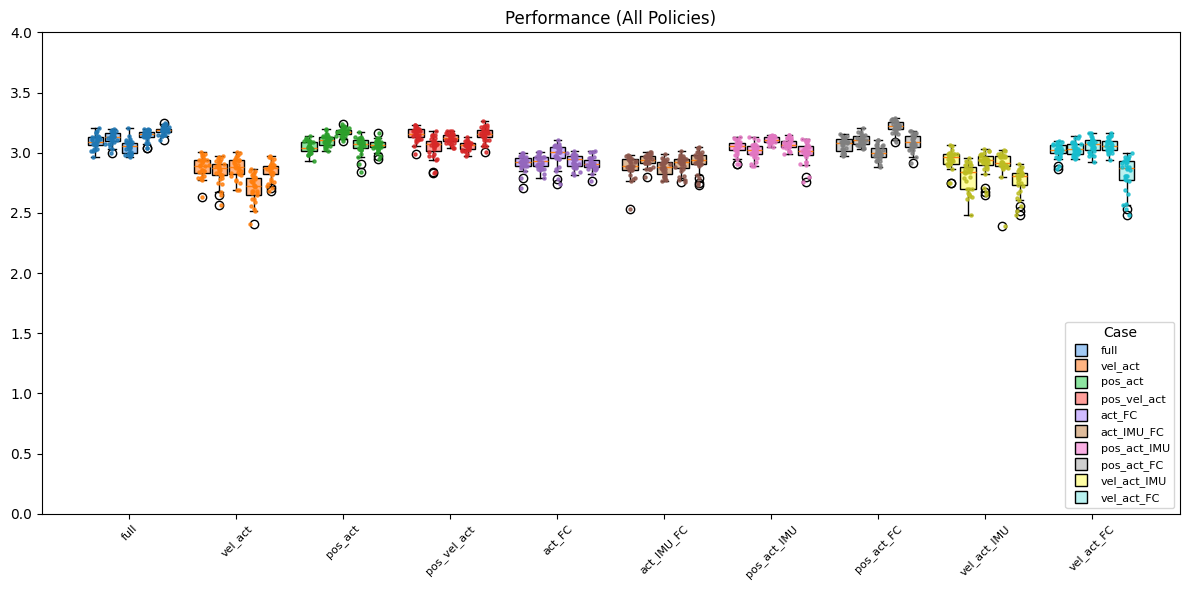

ranking : [('full', 3.1191203594207764), ('pos_vel_act', 3.106912612915039), ('pos_act_FC', 3.095398187637329), ('pos_act', 3.088132381439209), ('pos_act_IMU', 3.048147678375244), ('vel_act_FC', 2.9993233680725098), ('act_FC', 2.9328765869140625), ('act_IMU_FC', 2.9064900875091553), ('vel_act_IMU', 2.865860939025879), ('vel_act', 2.8317184448242188)]
---------------------------------------------------------


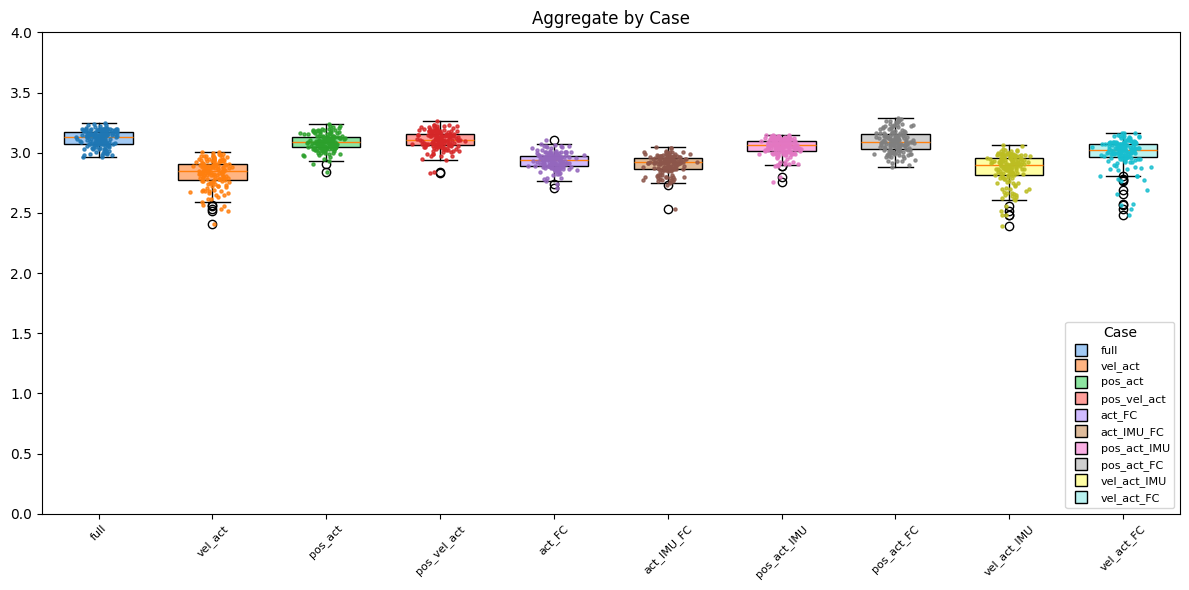

{'full': 3.1191203594207764, 'vel_act': 2.8317184448242188, 'pos_act': 3.088132381439209, 'pos_vel_act': 3.106912612915039, 'act_FC': 2.9328765869140625, 'act_IMU_FC': 2.9064900875091553, 'pos_act_IMU': 3.048147678375244, 'pos_act_FC': 3.095398187637329, 'vel_act_IMU': 2.865860939025879, 'vel_act_FC': 2.9993233680725098}
ranking : [('full', 3.1191203594207764), ('pos_vel_act', 3.106912612915039), ('pos_act_FC', 3.095398187637329), ('pos_act', 3.088132381439209), ('pos_act_IMU', 3.048147678375244), ('vel_act_FC', 2.9993233680725098), ('act_FC', 2.9328765869140625), ('act_IMU_FC', 2.9064900875091553), ('vel_act_IMU', 2.865860939025879), ('vel_act', 2.8317184448242188)]
---------------------------------------------------------
---------------------------------------------------------
---------------------------------------------------------
ranking : [('full', 3.1191203594207764), ('pos_vel_act', 3.106912612915039), ('pos_act_FC', 3.095398187637329), ('pos_act', 3.088132381439209), ('pos_

In [9]:
stats = plot_performance_all_in_one(max_distance, title="Performance (All Policies)",ylim=4)
# print(stats["overall_case_mean"])     # average for each case across all policies
# print(stats["policy_case_mean"])      # average per policy per case
ranking = sorted(stats["overall_case_mean"].items(), key=lambda kv: kv[1], reverse=True)
print(f"ranking : {ranking}")
print("---------------------------------------------------------")



case_means = plot_performance_aggregate(max_distance, title="Aggregate by Case",ylim=4)
print(case_means)  # {'caseA': 123.4, 'caseB': ...}
print(f"ranking : {sorted(case_means.items(), key=lambda kv: kv[1], reverse=True)}")




print("---------------------------------------------------------")
print("---------------------------------------------------------")
print("---------------------------------------------------------")
print(f"ranking : {ranking}")
print(f"ranking : {sorted(case_means.items(), key=lambda kv: kv[1], reverse=True)}")
